In [13]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get TIMIT pandas for metadata

In [5]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/').glob('*.pdpkl'))
df_path = df_paths[0]

In [7]:
meta_df = pd.read_pickle(df_path)

In [8]:
meta_df.head()

,_original_timit_index,word,source,speaker,sr,signal_length,speaker_sex,sentence_type,sentence_id,dialect_region,...,cue_speaker,mixture_signal,distractor_signal,_original_distractor_timit_indices,distractor_words,distractor_speakers,distractor_conditions,distractor_sex,snrs,cue_snr
0,612,example,train-dr2-faem0-si1392,faem0,20000,40000,f,si,1392,dr2,...,faem0,"[0.021357156322350076, 0.025801433713278345, 0...","[0.02598474168034081, 0.031491083300063366, 0....","[8857, 2405, 7933, 6424]","[ended, particularly, served, famous]","[mdrm0, mdhs0, mmdb1, mded0]",4,mmmm,-3,-3.0
1,627,their,train-dr2-fajw0-si1263,fajw0,20000,40000,f,si,1263,dr2,...,fajw0,"[0.006548380849468521, -0.012040014591002571, ...","[0.0011939308156294099, -0.0010738329924349312...",ssn,ssn,ssn,ssn,ssn,3,3.0
2,3134,majority,train-dr4-falr0-si1325,falr0,20000,40000,f,si,1325,dr4,...,falr0,"[0.0038653575644131857, 0.003787759285211831, ...","[-0.002291699611663041, -0.0022297216028135344...",[6610],[appointed],[mgsl0],1,m,-6,-6.0
3,5345,child,train-dr6-fapb0-sx343,fapb0,20000,40000,f,sx,343,dr6,...,fapb0,"[8.660285461392886e-06, 3.727941454883223e-05,...","[-0.0001617722662905093, 7.303222581187876e-05...",[1176],[group],[mdss0],1,m,-6,-6.0
4,9127,after,test-dr5-fawf0-sx190,fawf0,20000,40000,f,sx,190,dr5,...,fawf0,"[-0.003458555431358873, 0.007210018764692847, ...","[-0.005181012093857272, 0.010682500949803667, ...","[1732, 3999, 6913, 7922]","[their, judge, began, black]","[mrlj0, mpeb0, mrmg0, mjar0]",4,mmmm,-6,-6.0


### Get experimental results csv

In [9]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/')
results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')



In [10]:
results_df.head()

,HITId,HITTypeId,Title,Description,Keywords,Reward,CreationTime,MaxAssignments,RequesterAnnotation,AssignmentDurationInSeconds,...,Answer.trial_end_time_array,Answer.trial_start_time_array,Answer.userAgent,Answer.windowHeight,Answer.windowWidth,Answer.workerID,Answer.yrs_music,Answer.yrs_music_training,Approve,Reject
0,3Y7LTZE0YTUFA3H279SK2I2IC6QZUI,3QH037L2CMDARQ6IK9X3OTPWWVMAWH,Experiment - attentive listening task,Complete an auditory perception experiment - r...,"auditory, bonus, listening, headphones, psycho...",$0.00,Fri Oct 21 14:24:33 PDT 2022,10,BatchId:367265;OriginalHitTemplateId:920937243;,7200,...,Sun Oct 23 2022 11:14:04 GMT-0400 (Eastern Day...,Sun Oct 23 2022 11:13:50 GMT-0400 (Eastern Day...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,624,1890,A19YWY6E1CP566,14,6,NaN,NaN


#### Process results csv to plotting format

In [17]:
truth = results_df[[col for col in list(results_df) if 'Audio_Exp' in col]]
truth = truth.T
truth = truth.rename(columns={0:"stim_file_name"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})

In [18]:
truth.head()

,stim_file_name
trial 0,https://mcdermottlab.mit.edu/mturk_stimuli/img...
trial 1,https://mcdermottlab.mit.edu/mturk_stimuli/img...
trial 10,https://mcdermottlab.mit.edu/mturk_stimuli/img...
trial 100,https://mcdermottlab.mit.edu/mturk_stimuli/img...
trial 101,https://mcdermottlab.mit.edu/mturk_stimuli/img...


In [97]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om4/group/mcdermott/user/jfeather/projects/model_metamers/figure_generation_notebooks/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return word, snr, cond, speaker_sex, int(orig_df_ix)

word, snr, cond, speaker_sex, orig_df_ix = file_name_to_labels(file_name)
print(file_name)
print(f"{word} at {snr} dB snr with {cond} target sex ({speaker_sex}), original ix = {orig_df_ix}")




https://mcdermottlab.mit.edu/mturk_stimuli/imgriff/timit_attentive_listening_task/four_distractor_0dB_snr/set_00_stim_152_cond_4_snr_0_word_288_speaker_f.wav
friends at 0 dB snr with 4 target sex (f), original ix = 152


In [98]:
truth['true_word'], truth['snr'], truth['distractor_condition'], truth['target_sex'], truth['orig_df_ix'] = zip(*truth['stim_file_name'].map(file_name_to_labels))


In [99]:
responses = results_df[[col for col in list(results_df) if 'Resp_Exp' in col]]
responses = responses.T
responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})

In [100]:
results = responses.join(truth)

In [101]:
results.distractor_sex.unique()

array(['f', 'm', 'ssn'], dtype=object)

In [103]:
### Get metadata from timit df 
results['distractor_words'] = meta_df.loc[results.orig_df_ix, ['distractor_words']].values
results['distractor_sex'] = meta_df.loc[results.orig_df_ix, ['distractor_sex']].values


In [104]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [105]:
results.distractor_words[1]

array(['through', 'place', 'change', 'means'], dtype=object)

In [106]:
(results['guessed_word'].isin(results.distractor_words.values)).any()

False

In [124]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [ ]:
fig, axs = plt.subplots(1,3, sharey=True, figsize=(15,5))
axs = axs.ravel()

snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_acc_data, x='snr_condition', y='accuracy',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=snr_order
)


g1 = sn.pointplot(
    data=conf_data,
    x='snr_condition',y='confusions',
    hue='model',# hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1], 
    palette='colorblind', order=snr_order
)


g2 = sn.pointplot(
    data=bg_acc_data, x='snr_condition', y='accuracy',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette='colorblind', order=snr_order
)



axs[0].set_title("Performance on two-talker mixture")
axs[1].set_title("Errors from target-distractor confusion")
axs[2].set_title("Performance on single-talker in noise")


axs[0].set_ylabel("Prop. trials target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")
axs[2].set_ylabel("Prop. trials target word correct")

axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))

# axs[0].legend(title='distractor in training', loc='lower right', frameon=False)
axs[0].get_legend().remove()
axs[1].legend(title='distractor in training', loc='upper left', frameon=False)
# axs[2].legend(title='distractor in training', frameon=False)
axs[2].get_legend().remove()


plt.tight_layout()



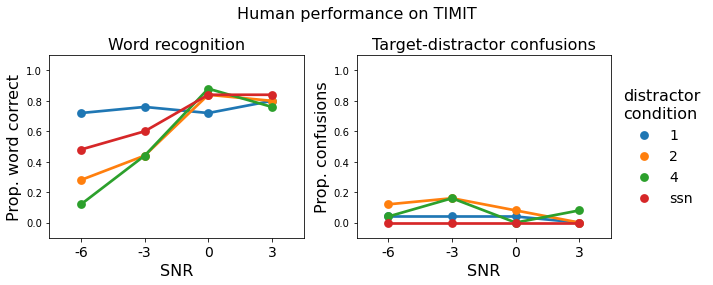

In [227]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Human performance on TIMIT', size=fontsize)
plt.tight_layout()


In [220]:
y_labels = np.linspace(-0.1,1.1,5).round(2)


In [221]:
y_labels

array([-0.1,  0.2,  0.5,  0.8,  1.1])

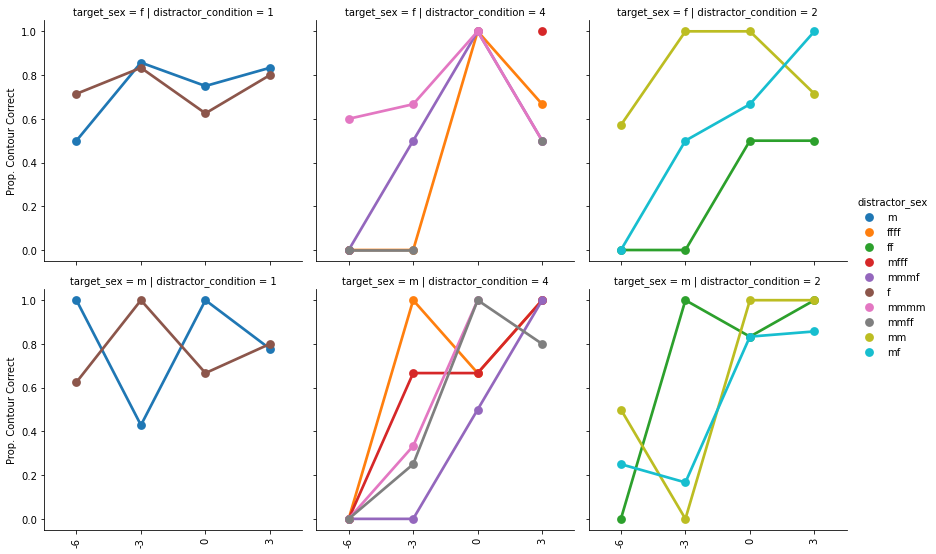

In [116]:
talker_hue_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']
g = sn.catplot( kind='point',
    data=results[results['distractor_condition'].isin(talker_hue_order)], 
    x='snr', y='accuracy',
    row='target_sex', 
    col='distractor_condition',
    hue='distractor_sex',
#     hue_order=talker_hue_order,
    ci=None, seed=1,
     height=4,
#     palette=sns.dark_palette("seagreen", reverse=True, as_cmap=False),
   order=snr_order,
)


g.set_xticklabels(rotation=90)
g.set_axis_labels("", "Prop. Contour Correct")
# plt.ylim(0, 1)
